In [1]:
!pip install beautifulsoup4 requests pandas

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
from IPython.display import clear_output  # For Colab output clearing

# Configure headers to mimic a browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

def scrape_product_page(url):
    """Scrape details from individual product page"""
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')

        details = {
            'description': soup.find('div', class_='description').get_text(strip=True) if soup.find('div', class_='description') else None,
            'reviews': [review.get_text(strip=True) for review in soup.find_all('div', class_='review-content')] or None,
            'rating': len(soup.find('div', class_='ratings').find_all('span', class_='glyphicon-star')) if soup.find('div', class_='ratings') else None
        }
        return details
    except Exception as e:
        print(f"⚠ Error scraping {url}: {str(e)[:100]}...")  # Truncate long errors
        return {'description': None, 'reviews': None, 'rating': None}

def scrape_ecommerce_site(base_url, max_pages=2):
    """Main scraping function with progress tracking"""
    all_products = []

    for page in range(1, max_pages + 1):
        clear_output(wait=True)  # Clear Colab output between pages
        print(f"📖 Scraping Page {page}/{max_pages}...")

        try:
            url = f"{base_url}/page/{page}" if page > 1 else base_url
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()

            soup = BeautifulSoup(response.text, 'html.parser')
            products = soup.find_all('div', class_='thumbnail')

            for idx, product in enumerate(products, 1):
                print(f"🛒 Processing product {idx}/{len(products)} on page {page}")

                product_data = {
                    'title': product.find('a', class_='title').get_text(strip=True) if product.find('a', class_='title') else None,
                    'price': float(product.find('h4', class_='price').get_text(strip=True).replace('$', '')) if product.find('h4', class_='price') else None,
                    'image_url': product.find('img')['src'] if product.find('img') else None
                }

                if product.find('a', class_='title'):
                    product_url = "https://webscraper.io" + product.find('a', class_='title')['href']
                    product_data.update(scrape_product_page(product_url))

                all_products.append(product_data)
                time.sleep(random.uniform(0.5, 1.5))  # Polite delay

        except Exception as e:
            print(f"❌ Page {page} failed: {str(e)[:100]}...")
            continue

    return all_products

def save_to_csv(data, filename='ecommerce_products.csv'):
    """Save data to CSV and provide download link in Colab"""
    df = pd.DataFrame(data)

    # Clean list-type data for CSV
    if 'reviews' in df.columns:
        df['reviews'] = df['reviews'].apply(lambda x: ' | '.join(x) if isinstance(x, list) else x)

    df.to_csv(filename, index=False, encoding='utf-8')

    # For Google Colab: Create download link
    from google.colab import files
    files.download(filename)

    return df

# Main execution
print("🚀 Starting Web Scraper...")
BASE_URL = "https://webscraper.io/test-sites/e-commerce/allinone"

try:
    products = scrape_ecommerce_site(BASE_URL, max_pages=2)
    if products:
        df = save_to_csv(products)
        print("\n✅ Scraping Completed Successfully!")
        print("\n📊 Sample Data:")
        display(df.head())  # Colab-friendly display
    else:
        print("❌ No data scraped - check website structure")
except Exception as e:
    print(f"💥 Critical Error: {e}")

📖 Scraping Page 2/2...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Scraping Completed Successfully!

📊 Sample Data:


,title,price,image_url,description,reviews,rating
0,Acer Extensa 1...,439.73,/images/test-sites/e-commerce/items/cart2.png,None,None,0
1,Hewlett Packar...,1273.11,/images/test-sites/e-commerce/items/cart2.png,None,None,0
2,Iconia B1-730H...,99.99,/images/test-sites/e-commerce/items/cart2.png,None,None,0


...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['rating']
  ys = series['price']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('rating', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('title')):
  _plot_series(series, series_name, i)
  fig.legend(title='title', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('rating')
_ = plt.ylabel('price')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['rating']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'rating'}, axis=1)
              .sort_values('rating', ascending=True))
  xs = counted['rating']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('rating', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('title')):
  _plot_series(series, series_name, i)
  fig.legend(title='title', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('rating')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_4['price'].plot(kind='line', figsize=(8, 4), title='price')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_5['title'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_5, x='price', y='title', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

🔍 Data Analysis Results:
Total Products: 3
Average Price: $604.28
Highest Rated Product: Acer Extensa 1...
🔍 Data Analysis Results:
Total Products: 3
Average Price: $604.28
Highest Rated Product: Acer Extensa 1...


<Axes: title={'center': 'Price Distribution'}, ylabel='Frequency'>

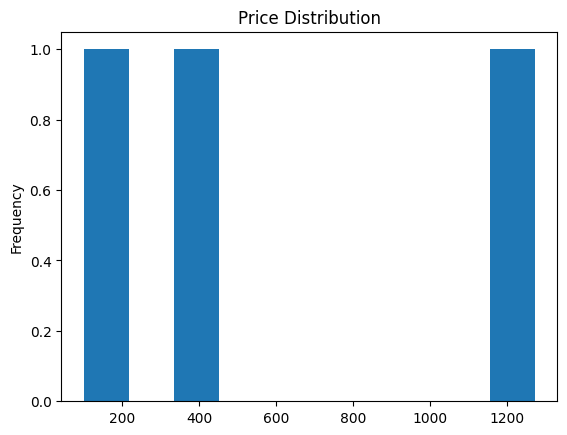

In [5]:
import pandas as pd

# Load the scraped data
df = pd.read_csv('ecommerce_products.csv')

# Basic analysis
print("🔍 Data Analysis Results:")
print(f"Total Products: {len(df)}")
print(f"Average Price: ${df['price'].mean():.2f}")
print(f"Highest Rated Product: {df.loc[df['rating'].idxmax()]['title']}")
import pandas as pd

# Load the scraped data
df = pd.read_csv('ecommerce_products.csv')

# Basic analysis
print("🔍 Data Analysis Results:")
print(f"Total Products: {len(df)}")
print(f"Average Price: ${df['price'].mean():.2f}")
print(f"Highest Rated Product: {df.loc[df['rating'].idxmax()]['title']}")

# Show price distribution
df['price'].plot(kind='hist', title='Price Distribution', bins=10)

🔍 Data Analysis Results:
Total Products: 3
Average Price: $604.28
Highest Rated Product: Acer Extensa 1...


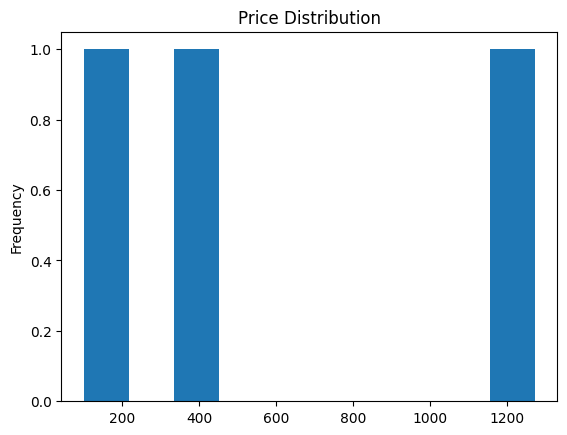


🏆 Top Products by Reviews:


,title,review_count
0,Acer Extensa 1...,1
1,Hewlett Packar...,1
2,Iconia B1-730H...,1



💲 Average Price by Rating:


,price
rating,
0,604.276667


In [7]:
import pandas as pd

# Load the scraped data
df = pd.read_csv('ecommerce_products.csv')

# Basic analysis
print("🔍 Data Analysis Results:")
print(f"Total Products: {len(df)}")
print(f"Average Price: ${df['price'].mean():.2f}")

# Handle potential NaN values in 'rating' before finding idxmax
if not df['rating'].dropna().empty:
    print(f"Highest Rated Product: {df.loc[df['rating'].idxmax()]['title']}")
else:
    print("Highest Rated Product: No ratings available")


# Show price distribution
# Ensure matplotlib is imported for plotting if not already
try:
    import matplotlib.pyplot as plt
    df['price'].plot(kind='hist', title='Price Distribution', bins=10)
    plt.show() # Display the plot
except ImportError:
    print("Matplotlib not installed. Cannot display plot.")
    print("Install with: !pip install matplotlib")


# Convert reviews from string to list (if needed)
# Fill NaN values with empty strings before splitting
df['reviews'] = df['reviews'].fillna('').str.split('|')

# 1. Products with most reviews
df['review_count'] = df['reviews'].apply(lambda x: len(x) if isinstance(x, list) else 0)
top_products = df.sort_values('review_count', ascending=False).head(3)

# 2. Price vs. Rating analysis
# Handle potential NaN values in 'rating' or 'price' before grouping
price_rating = df.dropna(subset=['rating', 'price']).groupby('rating')['price'].mean()

print("\n🏆 Top Products by Reviews:")
# Ensure display is imported if not already
from IPython.display import display
display(top_products[['title', 'review_count']])

print("\n💲 Average Price by Rating:")
display(price_rating)

In [13]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Define the directory path
drive_dir = '/content/drive/MyDrive/scraped_data'

# Check if the directory exists, and create it if it doesn't
if not os.path.exists(drive_dir):
    os.makedirs(drive_dir)
    print(f"Created directory: {drive_dir}")

# Define the full file path
file_path = os.path.join(drive_dir, 'ecommerce_products.csv')

# Save to your Drive
df.to_csv(file_path, index=False)
print(f"Saved to Google Drive at: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created directory: /content/drive/MyDrive/scraped_data
Saved to Google Drive at: /content/drive/MyDrive/scraped_data/ecommerce_products.csv
